# 🌱 GermiCount Dataset Analysis

This notebook provides a structured pipeline for downloading, summarizing, and visualizing seed dataset images.

### Pipeline Structure:
1. **Environment Setup**
2. **Quantitative Summary**
3. **Resolution Summary**
4. **Image Visualization**
   - **4.1 Sample Visualization Helper**
   - **4.2 Train Split Samples**
   - **4.3 Test Split Samples**
   - **4.4 Validation Split Samples**


## 1. Environment Setup

* Sets up Google Colab environment, imports libraries, and auto-downloads the dataset.


### 1.1 Imports

* `os`, `sys`, `glob`, `shutil`, `random` for file paths and system utilities
* `cv2` and `pandas` for image processing and table handling
* `matplotlib.pyplot` and `IPython.display` for rendering plots and tables


In [64]:
import os
import sys
import glob
import shutil
import random
import cv2
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

### 1.2 Setup Environment

* Configures plot DPI (`120`) for sharp image display
* Prints confirmation message


In [65]:
def setup_environment():
    """Configure plot aesthetics for crisp image rendering in Google Colab / Jupyter."""
    plt.rcParams['figure.dpi'] = 120
    print(" Environment setup configured successfully.")

### 1.3 Dataset Downloader

* Auto-installs `kagglehub` if missing
* Downloads dataset from Kaggle into local workspace
* Skips download if dataset directory already exists


In [66]:
def download_and_setup_dataset(dataset_dir="dataset"):
    """Automatically install kagglehub and download dataset into local workspace."""
    abs_dataset_dir = os.path.abspath(dataset_dir)
    if os.path.exists(abs_dataset_dir) and any(os.scandir(abs_dataset_dir)):
        print(f" Dataset directory already exists at: '{abs_dataset_dir}'")
        return abs_dataset_dir
    try:
        import kagglehub
    except ImportError:
        import subprocess
        print(" Installing kagglehub...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "kagglehub"])
        import kagglehub
    print(" Downloading dataset from Kaggle...")
    kaggle_path = kagglehub.dataset_download("shajinrp/germinated-and-non-germinated-seed")
    source_dir = os.path.join(kaggle_path, "seed germ") if os.path.exists(os.path.join(kaggle_path, "seed germ")) else kaggle_path
    if not os.path.exists(abs_dataset_dir):
        shutil.copytree(source_dir, abs_dataset_dir)
        print(f" Dataset successfully downloaded and saved to: '{abs_dataset_dir}'")
    return abs_dataset_dir

### 1.4 Run Setup

* Runs environment setup and dataset download functions
* Sets split paths (`['train', 'val', 'test']`) and class mappings (`{0: 'Germinated', 1: 'Non-Germinated'}`)


In [67]:
# Configure display environment
setup_environment()

 Environment setup configured successfully.


In [68]:
# Download dataset and store directory path
DATASET_DIR = download_and_setup_dataset()

 Dataset directory already exists at: '/content/dataset'


In [69]:
# Define global splits and class mappings
SPLITS = ['train', 'val', 'test']
CLASS_NAMES = {0: 'Germinated', 1: 'Non-Germinated'}

## 2. Quantitative Summary

* Parses YOLO annotations and computes summary metrics across dataset splits.


### 2.1 Parse Label File

* Reads bounding box coordinates (`x_center`, `y_center`, `width`, `height`)
* Calculates box area, aspect ratio, and class counts (`Germinated` vs `Non-Germinated`)
* Computes germination rate percentage per image


In [70]:
def parse_single_label_file(lbl_path, split, class_names):
    """Parse a single YOLO label file and extract bounding box records."""
    file_name = os.path.basename(lbl_path)
    box_records = []
    count_0, count_1 = 0, 0
    with open(lbl_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls_id = int(parts[0])
                xc, yc, w, h = [float(v) for v in parts[1:5]]
                if cls_id == 0:
                    count_0 += 1
                elif cls_id == 1:
                    count_1 += 1
                box_records.append({
                    'split': split,
                    'file_name': file_name,
                    'class_id': cls_id,
                    'class_name': class_names.get(cls_id, f"Class {cls_id}"),
                    'x_center': xc,
                    'y_center': yc,
                    'width': w,
                    'height': h,
                    'area': w * h,
                    'aspect_ratio': w / h if h > 0 else 0
                })
    total_img_seeds = count_0 + count_1
    germ_rate = (count_0 / total_img_seeds * 100.0) if total_img_seeds > 0 else 0.0
    img_record = {
        'split': split,
        'file_name': file_name,
        'germinated': count_0,
        'non_germinated': count_1,
        'total_seeds': total_img_seeds,
        'germination_rate_pct': germ_rate
    }
    return box_records, img_record, count_0, count_1

### 2.2 Collect Dataset Stats

* Iterates through `train`, `val`, and `test` split folders
* Counts total images, label files, and seed instances
* Returns structured DataFrames for split summaries and box records


In [71]:
def collect_quantitative_data(dataset_dir, splits=SPLITS, class_names=CLASS_NAMES):
    """Iterate across splits and collect quantitative DataFrames for boxes, images, and splits summary."""
    all_box_records = []
    all_img_records = []
    split_summary = []
    for split in splits:
        split_dir = os.path.join(dataset_dir, split)
        img_dir = os.path.join(split_dir, "images") if os.path.exists(os.path.join(split_dir, "images")) else os.path.join(split_dir, "image")
        lbl_dir = os.path.join(split_dir, "labels") if os.path.exists(os.path.join(split_dir, "labels")) else os.path.join(split_dir, "label")
        img_files = glob.glob(os.path.join(img_dir, "*.*")) if os.path.exists(img_dir) else []
        lbl_files = glob.glob(os.path.join(lbl_dir, "*.txt")) if os.path.exists(lbl_dir) else []
        split_germ, split_non_germ = 0, 0
        for lbl_path in lbl_files:
            b_recs, i_rec, c0, c1 = parse_single_label_file(lbl_path, split, class_names)
            all_box_records.extend(b_recs)
            all_img_records.append(i_rec)
            split_germ += c0
            split_non_germ += c1
        total_split_seeds = split_germ + split_non_germ
        split_summary.append({
            'Split': split.capitalize(),
            'Total Images': len(img_files),
            'Label Files': len(lbl_files),
            'Germinated Seeds ()': split_germ,
            'Non-Germinated Seeds ()': split_non_germ,
            'Total Bounding Boxes': total_split_seeds,
            'Avg Seeds / Image': round(total_split_seeds / len(img_files), 2) if len(img_files) > 0 else 0
        })
    return pd.DataFrame(split_summary), pd.DataFrame(all_img_records), pd.DataFrame(all_box_records)

### 2.3 Run Quantitative Summary

* Runs data collection across all dataset splits
* Displays tabular summary of image totals, label counts, and seed density


In [72]:
# Extract quantitative split summary dataframe
df_splits, _, _ = collect_quantitative_data(DATASET_DIR, SPLITS, CLASS_NAMES)

In [73]:
# Display summary dataframe table
print("===  Quantitative Dataset Split Summary ===")
display(df_splits)

===  Quantitative Dataset Split Summary ===


,Split,Total Images,Label Files,Germinated Seeds (),Non-Germinated Seeds (),Total Bounding Boxes,Avg Seeds / Image
0,Train,240,240,1368,1032,2400,10.0
1,Val,30,30,43,257,300,10.0
2,Test,30,30,33,267,300,10.0


## 3. Resolution Summary

* Scans image dimensions and summarizes resolution metrics.


### 3.1 Extract Image Metadata

* Loads image with OpenCV (`cv2.imread`)
* Extracts width, height, channel count, and aspect ratio


In [74]:
def get_single_image_metadata(img_path, split):
    """Extract resolution and metadata dict for a single image file."""
    img = cv2.imread(img_path)
    if img is None:
        return None
    h, w, c = img.shape
    return {
        'split': split,
        'file_name': os.path.basename(img_path),
        'width': w,
        'height': h,
        'resolution': f"{w}x{h}",
        'aspect_ratio': round(w / h, 3),
        'channels': c
    }

### 3.2 Collect Resolution Data

* Scans image files across all dataset splits
* Builds a metadata DataFrame of spatial dimensions


In [75]:
def collect_resolution_data(dataset_dir, splits=SPLITS):
    """Collect image resolution metadata across all dataset splits."""
    res_records = []
    for split in splits:
        split_dir = os.path.join(dataset_dir, split)
        img_dir = os.path.join(split_dir, "images") if os.path.exists(os.path.join(split_dir, "images")) else os.path.join(split_dir, "image")
        img_files = glob.glob(os.path.join(img_dir, "*.*")) if os.path.exists(img_dir) else []
        for img_path in img_files:
            meta = get_single_image_metadata(img_path, split)
            if meta is not None:
                res_records.append(meta)
    return pd.DataFrame(res_records)

### 3.3 Summarize Resolutions

* Groups image metrics by split (`train`, `val`, `test`)
* Computes mean width, height, aspect ratio, and unique resolutions


In [76]:
def summarize_resolutions(df_resolutions):
    """Compute summary table for image dimensions grouped by split."""
    if df_resolutions.empty:
        return None
    return df_resolutions.groupby('split').agg(
        Total_Images=('file_name', 'count'),
        Resolutions=('resolution', lambda x: list(set(x))),
        Mean_Width=('width', 'mean'),
        Mean_Height=('height', 'mean'),
        Mean_Aspect_Ratio=('aspect_ratio', 'mean')
    ).reset_index()

### 3.4 Run Resolution Summary

* Runs resolution data collection
* Displays summary table of image dimensions per split


In [77]:
# Extract image resolution metadata
df_resolutions = collect_resolution_data(DATASET_DIR, SPLITS)

In [78]:
# Display resolution summary table
res_summary = summarize_resolutions(df_resolutions)
if res_summary is not None:
    print("===  Image Resolution Summary ===")
    display(res_summary)

===  Image Resolution Summary ===


,split,Total_Images,Resolutions,Mean_Width,Mean_Height,Mean_Aspect_Ratio
0,test,30,[624x624],624.0,624.0,1.0
1,train,240,[624x624],624.0,624.0,1.0
2,val,30,[624x624],624.0,624.0,1.0


## 4. Image Visualization

* Visualizes sample dataset images in 2x2 grid layouts.


### 4.1 Sample Visualization Helper

* Samples random images reproducibly using a seed
* Converts OpenCV BGR images to RGB format
* Displays 4 sample images in a 2x2 Matplotlib grid


In [79]:
def visualize_random_images(dataset_dir, split="train", num_images=4, seed=None):
    """Load and display 4 clean random images from a dataset split in a 2x2 grid layout."""
    if seed is not None:
        random.seed(seed)
    split_dir = os.path.join(dataset_dir, split)
    img_dir = os.path.join(split_dir, "images") if os.path.exists(os.path.join(split_dir, "images")) else os.path.join(split_dir, "image")
    img_paths = sorted(glob.glob(os.path.join(img_dir, "*.*")))
    if not img_paths:
        print(f"[WARNING] No images found in split: '{split}' at path '{img_dir}'")
        return
    selected_paths = random.sample(img_paths, min(num_images, len(img_paths)))
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    axes_flat = axes.flatten()
    for idx in range(4):
        ax = axes_flat[idx]
        if idx < len(selected_paths):
            img_path = selected_paths[idx]
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            img = cv2.imread(img_path)
            if img is not None:
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img_rgb)
                ax.set_title(base_name, fontsize=10, fontweight='bold')
        ax.axis('off')
    fig.suptitle(f"Dataset Sample Images - {split.capitalize()} Split (2x2 Grid)", fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### 4.2 Train Split Samples

* Displays 4 random sample images from the `train` split


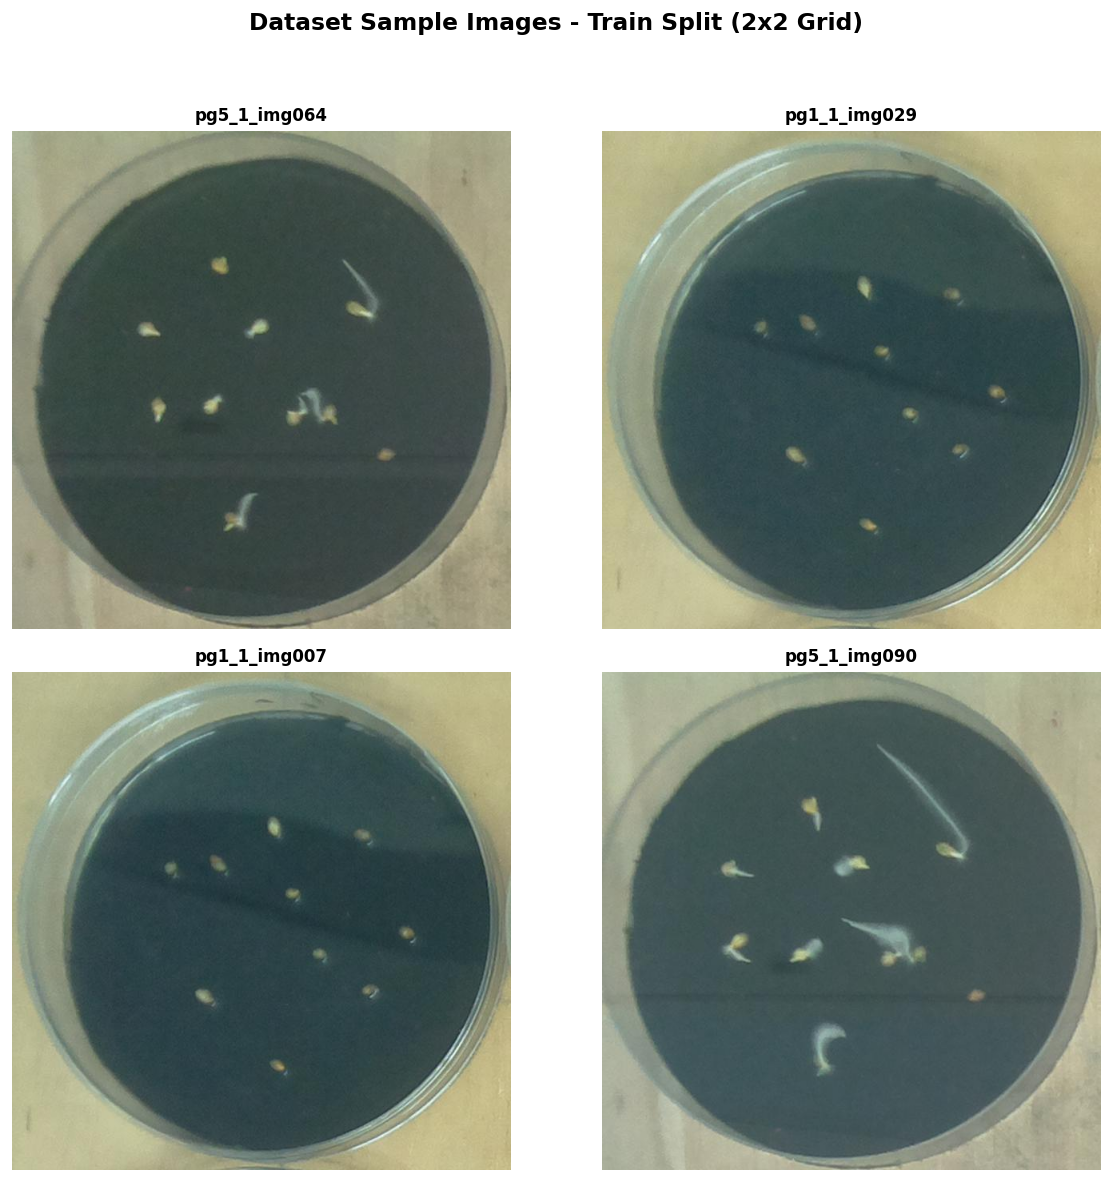

In [80]:
# Display 4 random images from the Train split in a 2x2 grid
visualize_random_images(DATASET_DIR, split='train', num_images=4, seed=42)

### 4.3 Test Split Samples

* Displays 4 random sample images from the `test` split


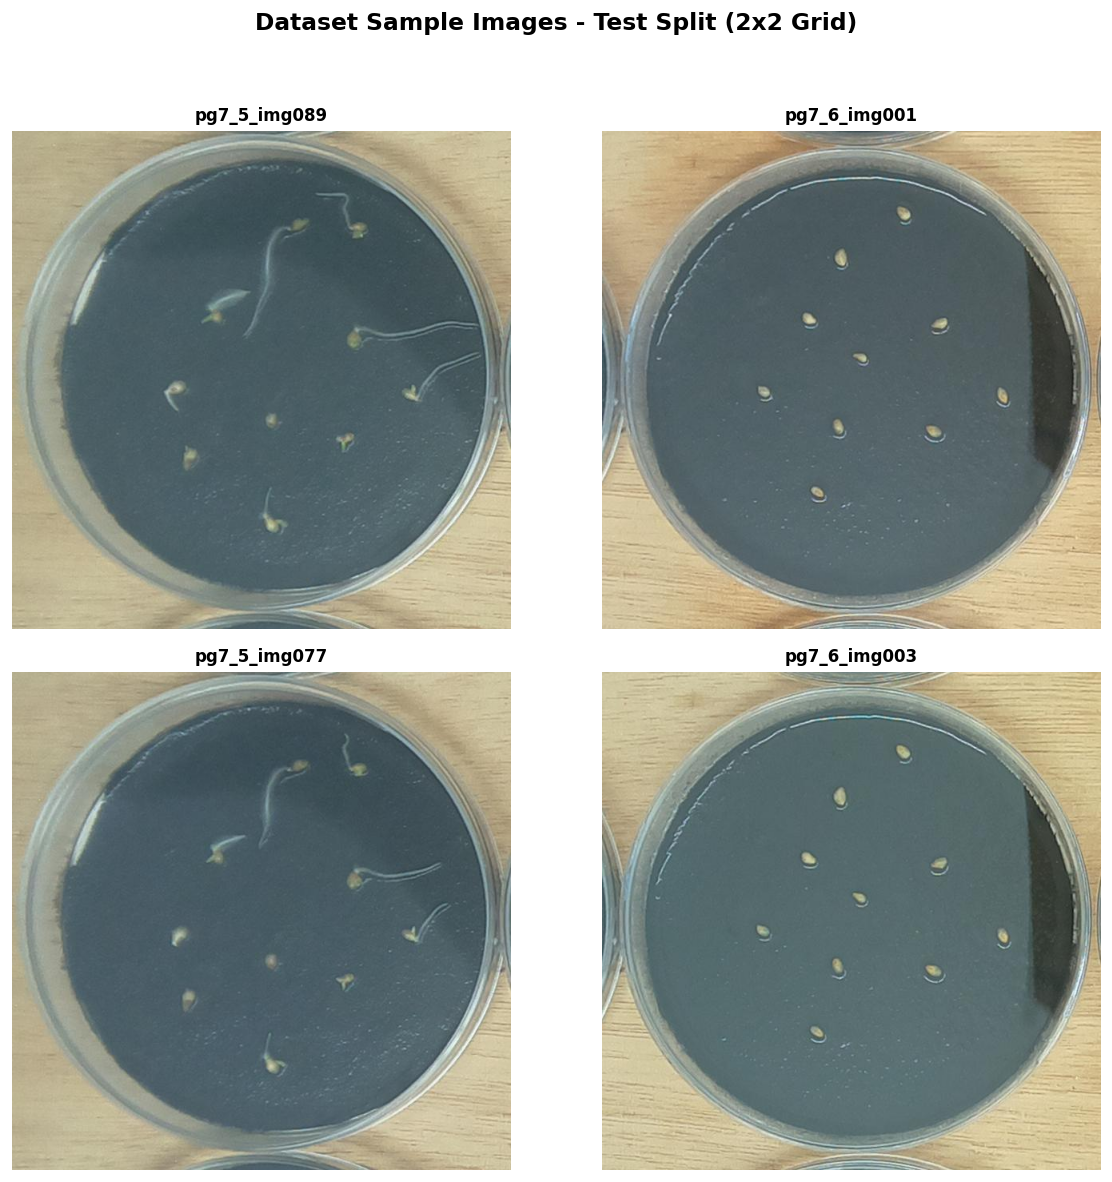

In [81]:
# Display 4 random images from the Test split in a 2x2 grid
visualize_random_images(DATASET_DIR, split='test', num_images=4, seed=101)

### 4.4 Validation Split Samples

* Displays 4 random sample images from the `val` split


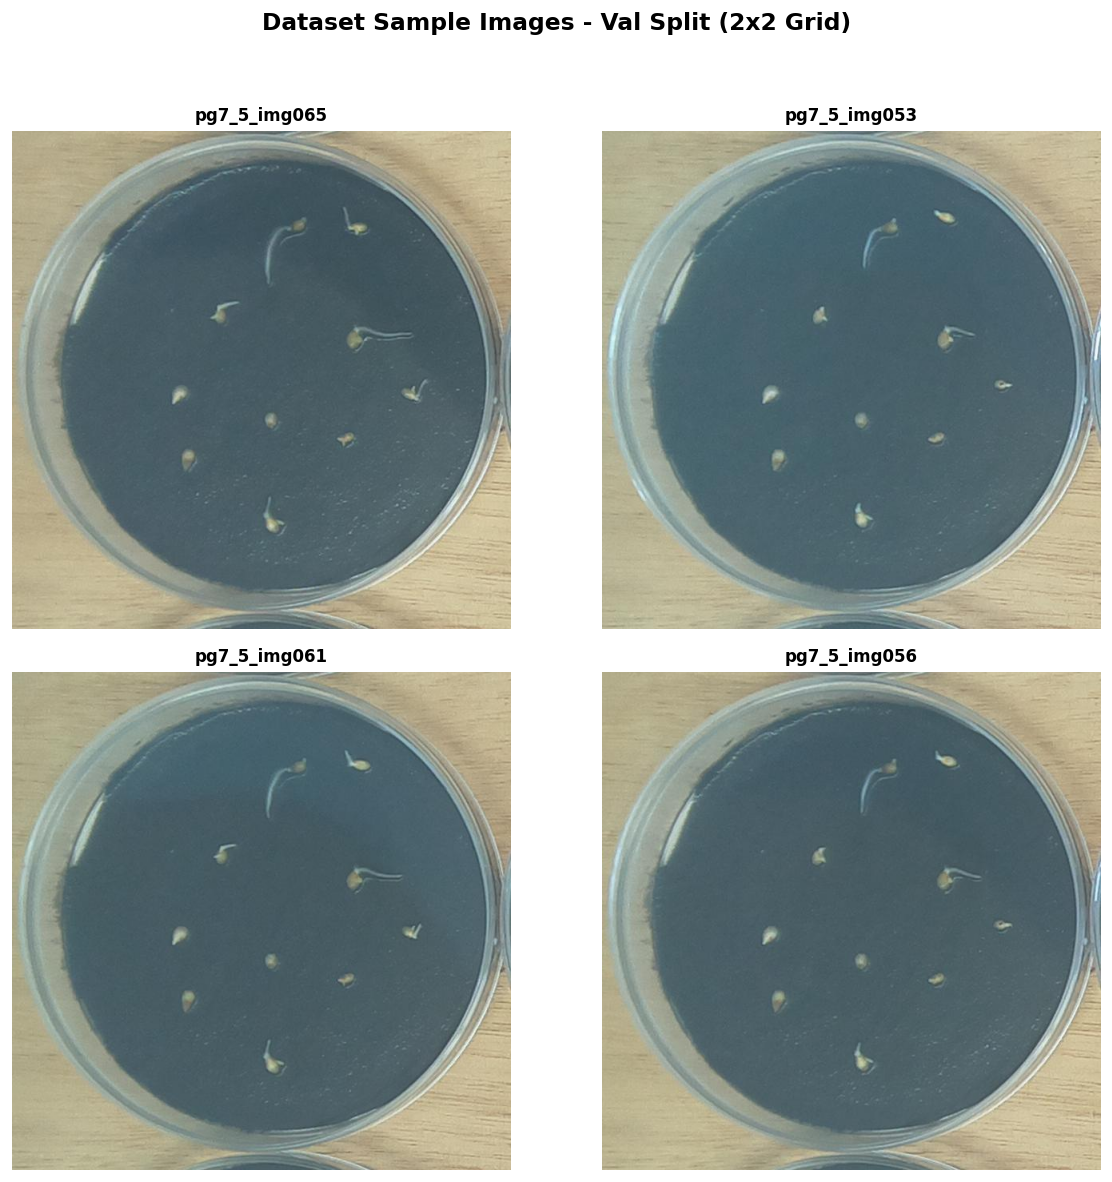

In [82]:
# Display 4 random images from the Validation split in a 2x2 grid
visualize_random_images(DATASET_DIR, split='val', num_images=4, seed=202)